In [2]:
import matplotlib.pyplot as plt
import numpy as np
from ham import *

print("Hamlib version:", hamlibversion())

Hamlib version: 0.1.4


In [12]:
calset_raw = load_calset("testdata/calibrated/calset_50K_50M.cal")
calibration_set = calibrate_set( calset_raw )

freq = []
short_s11 = []
load_s11 = []
open_s11 = []

for entry in calset_raw:
    f = entry['freq']
    cal = calibration_set.get(f)
    cal_short = apply_calibration(entry['short'], cal["Ed"], cal["Es"], cal["Er"])
    cal_load = apply_calibration(entry['load'], cal["Ed"], cal["Es"], cal["Er"])
    cal_open = apply_calibration(entry['open'], cal["Ed"], cal["Es"], cal["Er"])
    freq.append(f)
    short_s11.append(cal_short)
    load_s11.append(cal_load)
    open_s11.append(cal_open)

freq = np.array(freq)
short_s11 = np.array(short_s11)
load_s11 = np.array(load_s11)
open_s11 = np.array(open_s11)


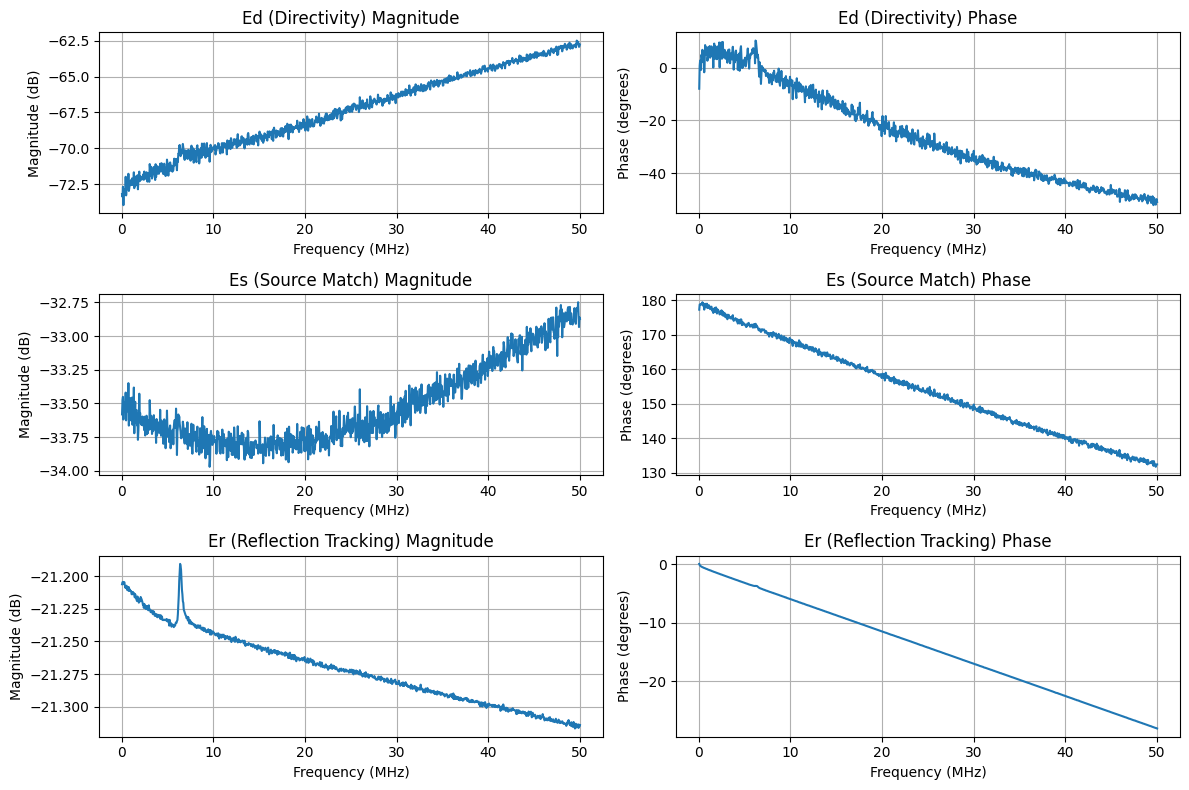

In [8]:
Ed = np.array([calibration_set[f]['Ed'] for f in freq])
Es = np.array([calibration_set[f]['Es'] for f in freq])
Er = np.array([calibration_set[f]['Er'] for f in freq])

plt.figure(figsize=(12, 8))

# Ed plots
plt.subplot(3, 2, 1)
plt.plot(freq / 1e6, 20 * np.log10(np.abs(Ed)))
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Magnitude (dB)")
plt.title("Ed (Directivity) Magnitude")
plt.grid()

plt.subplot(3, 2, 2)
plt.plot(freq / 1e6, np.angle(Ed, deg=True))
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Phase (degrees)")
plt.title("Ed (Directivity) Phase")
plt.grid()

# Es plots
plt.subplot(3, 2, 3)
plt.plot(freq / 1e6, 20 * np.log10(np.abs(Es)))
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Magnitude (dB)")
plt.title("Es (Source Match) Magnitude")
plt.grid()

plt.subplot(3, 2, 4)
plt.plot(freq / 1e6, np.angle(Es, deg=True))
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Phase (degrees)")
plt.title("Es (Source Match) Phase")
plt.grid()

# Er plots
plt.subplot(3, 2, 5)
plt.plot(freq / 1e6, 20 * np.log10(np.abs(Er)))
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Magnitude (dB)")
plt.title("Er (Reflection Tracking) Magnitude")
plt.grid()

plt.subplot(3, 2, 6)
plt.plot(freq / 1e6, np.angle(Er, deg=True))
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Phase (degrees)")
plt.title("Er (Reflection Tracking) Phase")
plt.grid()

plt.tight_layout()
plt.show()

C:\Users\jfabe\AppData\Local\Temp\ipykernel_13104\978201277.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(freq / 1e6, 20 * np.log10(np.abs(load_s11)), label="Load")


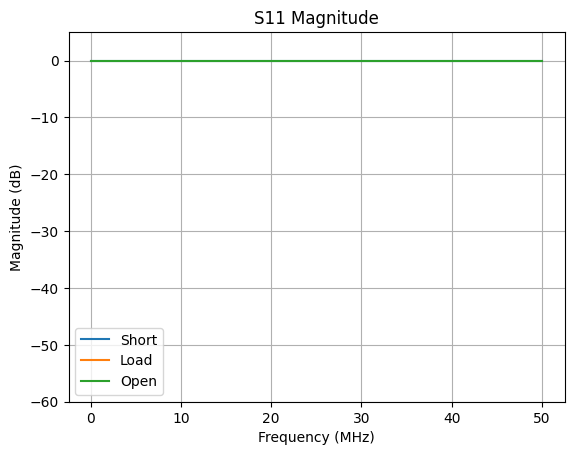

In [13]:
plt.plot(freq / 1e6, 20 * np.log10(np.abs(short_s11)), label="Short")
plt.plot(freq / 1e6, 20 * np.log10(np.abs(load_s11)), label="Load")
plt.plot(freq / 1e6, 20 * np.log10(np.abs(open_s11)), label="Open")
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Magnitude (dB)")
plt.title("S11 Magnitude")
plt.ylim(-60, 5)
plt.legend()
plt.grid()
plt.show()

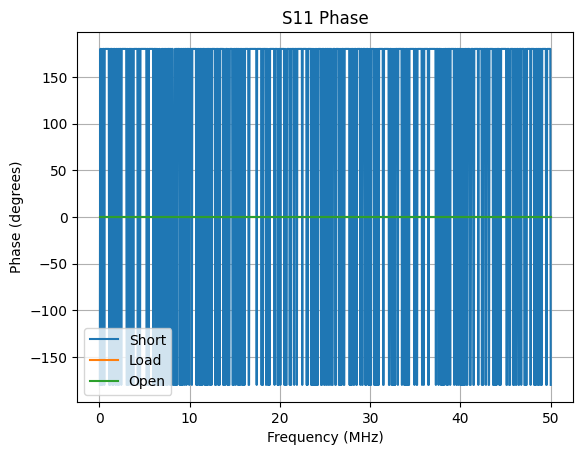

In [6]:
plt.plot(freq / 1e6, np.angle(short_s11, deg=True), label="Short")
plt.plot(freq / 1e6, np.angle(load_s11, deg=True), label="Load")
plt.plot(freq / 1e6, np.angle(open_s11, deg=True), label="Open")
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Phase (degrees)")
plt.title("S11 Phase")
plt.legend()
plt.grid()
plt.show()